In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [34]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "axes.titlesize":10,
     "axes.labelsize":10,
      "xtick.labelsize":10,
       "ytick.labelsize":10,

})
Random_state=42
dataset="Mall_Customers.csv"



In [35]:
df=pd.read_csv(dataset)

In [36]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [37]:
df.shape

(200, 5)

In [38]:
customer_id=df["CustomerID"]

In [39]:
df=df.drop(columns=["CustomerID"])

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [41]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [42]:
for col in df.columns:
    print(df[col].value_counts().head(10))

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
19     8
31     8
30     7
49     7
23     6
40     6
36     6
27     6
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
48     6
60     6
62     6
63     6
71     6
87     6
19     4
20     4
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
35    5
75    5
52    5
50    5
59    5
48    5
Name: count, dtype: int64


In [43]:
duplicated=df.duplicated()
num_duplicates=duplicated.sum()
print(f"Number of duplicated rows:",num_duplicates)

Number of duplicated rows: 0


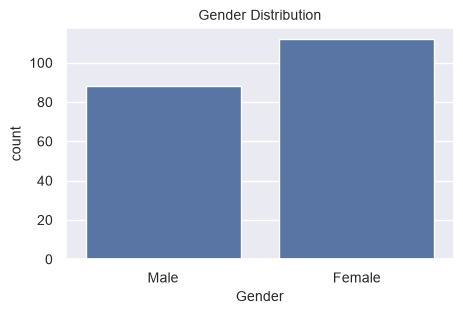

In [44]:
plt.figure(figsize=(5,3))
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()


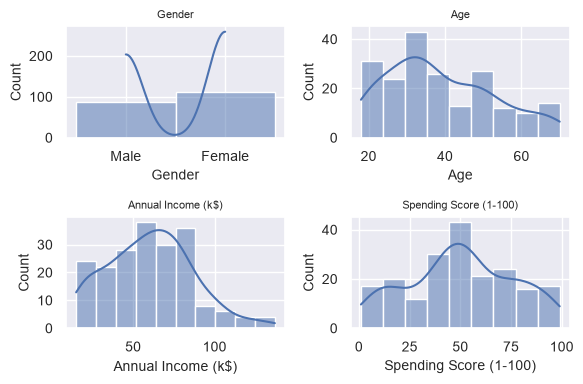

In [45]:
fig,axes=plt.subplots(2,2,figsize=(6,4))
axes=axes.flatten()
for i,col in enumerate(df.columns):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()

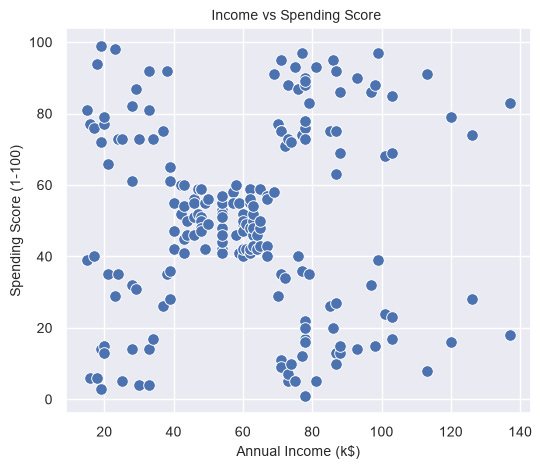

In [46]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Annual Income (k$)",
y="Spending Score (1-100)",
data=df,
s=70)
plt.title("Income vs Spending Score ")
plt.show()
#size of scatter plot -> s

Data Preprocessing

In [47]:
columns_to_select=['Annual Income (k$)',"Spending Score (1-100)"]
X=df[columns_to_select]

#choosing only imp features to avoid increasing of distance
#age is not that imp for for buying

In [48]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [49]:
#scale the features (k-means is distance-based)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [50]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

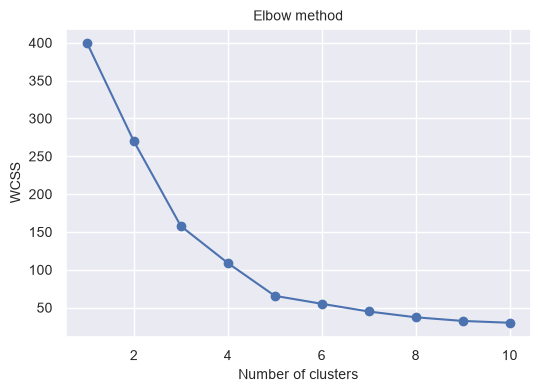

In [51]:
#finding k value using elbow method (optimal)
wcss=[] # inertia (within cluster sum of squares)
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=Random_state,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(list(k_range),wcss,marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

Inference

In [52]:
# to know check the decline in graph
# very steep drop from k:1->2->3
#after k=5 the curve starts flattening - From k=6 on ward the reduction in WCSS is marginal
# after k=5 the drop in difference is same 

K-Means Clustering

In [53]:
k_final=5
kmeans_final=KMeans(
    n_clusters=k_final,
    random_state=Random_state,
    n_init=10
)

In [54]:
kmeans_final.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[-0.

In [55]:
clusters=kmeans_final.predict(X_scaled)

In [56]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [57]:
df_clusters=df.copy(deep=True)
#any changes on copy donnt affect original by adding deep

In [58]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [59]:
df_clusters["clusters"]=clusters

In [60]:
df_clusters["CustomerID"]=customer_id

In [61]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5


In [62]:
k_means_score=silhouette_score(X_scaled,clusters)

In [63]:
print(f"K-Means clustering - Silhouette Score:",round(k_means_score,2))

K-Means clustering - Silhouette Score: 0.55


Silhouette score value ranges btw -1 to 1
perfect when score is 1 -> clusters are not overlapping
-1 means overlapping btw clusters
0 still some overlappings  exist

Text(0, 0.5, 'silhouette_score')

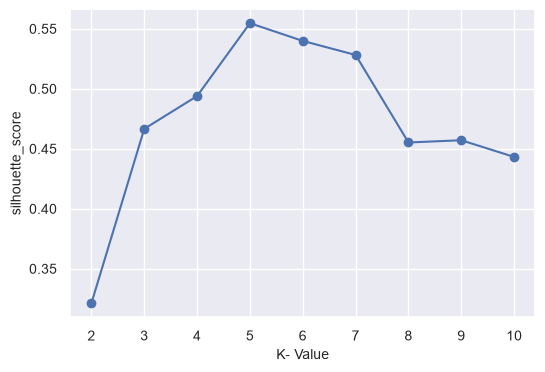

In [69]:
k_ranges=range(2,11)
sil_scores=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=Random_state,n_init=10)
    cluster_label=model.fit_predict(X_scaled)
    sil=silhouette_score(X_scaled,cluster_label)
    sil_scores.append(sil)
plt.figure(figsize=(6,4))
plt.plot(range(2,11),sil_scores,marker="o")
plt.xlabel("K- Value")
plt.ylabel("silhouette_score")


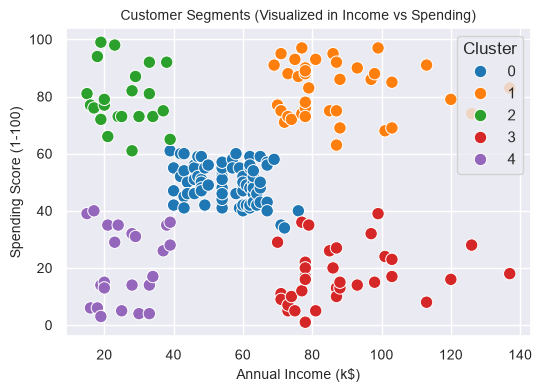

In [70]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df_clusters["Annual Income (k$)"],
    y=df_clusters["Spending Score (1-100)"],
    hue=df_clusters["clusters"],
    palette="tab10",
    s=80
)
plt.title("Customer Segments (Visualized in Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()
#hue colors based on clusters

Cluster Interpretation (Business Profiling)

In [71]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [76]:
profile_cols=['Age',"Annual Income (k$)","Spending Score (1-100)"]
cluster_sizes=df_clusters['clusters'].value_counts().sort_index()
cluster_profile_mean=df_clusters.groupby('clusters')[profile_cols].mean()
cluster_profile_median=df_clusters.groupby('clusters')[profile_cols].median()
print(cluster_sizes)
print(cluster_profile_mean)
print(cluster_profile_median)
#mean is not crt way to compare coz it  can contain outliers
# so use median


clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
            Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                   
0        42.716              55.296                  49.519
1        32.692              86.538                  82.128
2        25.273              25.727                  79.364
3        41.114              88.200                  17.114
4        45.217              26.304                  20.913
            Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                   
0        46.000              54.000                  50.000
1        32.000              79.000                  83.000
2        23.500              24.500                  77.000
3        42.000              85.000                  16.000
4        46.000              25.000                  17.000


Segement New Customer 

In [77]:
def predict_customer(income,spending_score,scaler,model):
    new_point=pd.DataFrame(
        [[income,spending_score]],
        columns=["Annual Income (k$)","Spending Score (1-100)"]
    )
    new_point_scaled=scaler.transform(new_point)
    cluster_id=model.predict(new_point_scaled)
    return cluster_id

In [80]:
new_cluster=predict_customer(
    income=10,
    spending_score=90,
    scaler=scaler,
    model=kmeans_final
)
print("New Customer assigned to cluster:",new_cluster)

New Customer assigned to cluster: [2]


### Export Model Artifacts for Deployment


In [ ]:
import joblib

# Export trained model and scaler
joblib.dump(kmeans_final, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("Artifacts successfully saved to model.joblib and scaler.joblib")
